## 1. Introducción y Conceptos
SHAP (SHapley Additive exPlanations) nos permitirá descomponer la probabilidad de riesgo de un cliente.

- **Agnóstico:** Funciona con Random Forest.

- **Local:** Explicacion de por qué a un cliente específico se le denegó el crédito.

## 2. Descarga y Carga de Datos (artifacts/)
Uso los archivos locales ya procesados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap
from pathlib import Path

In [2]:
# Definir la raíz del proyecto
root = Path.cwd()
# Subir niveles hasta encontrar la carpeta del proyecto si es necesario
while not (root / "artifacts").exists() and root.parent != root:
    root = root.parent

# Cargar artefactos usando la ruta 'root' ya definida
X_test_raw = joblib.load(root / "data/processed/X_test.pkl")
model = joblib.load(root / "artifacts/model/model.pkl")
cols_modelo = list(model.feature_names_in_)

# Convertir a DataFrame con las 19 columnas oficiales
X_test = pd.DataFrame(X_test_raw[:, :len(cols_modelo)], columns=cols_modelo)

print(f"✅ Proyecto localizado en: {root}")
print(f"✅ Datos cargados: {X_test.shape}")

✅ Proyecto localizado en: c:\projects\credit_risk_ml
✅ Datos cargados: (200, 19)


In [3]:
# Cargar artefactos
X_test_raw = joblib.load(root/"data/processed/X_test.pkl")
model = joblib.load(root / "artifacts/model/model.pkl")
cols_modelo = list(model.feature_names_in_)

# Convertir a DataFrame inmediatamente para habilitar .describe() y filtros
# Solo tomamos las primeras 19 columnas que el modelo reconoce
X_test = pd.DataFrame(X_test_raw[:, :len(cols_modelo)], columns=cols_modelo)

## 2. Exploración de Datos (Análisis de Variables)
Inspeccionar las 24 variables originales de tu X_test para entender qué tenemos antes de limpiar.

In [4]:
print("--- Estadísticas Exploratorias (EDA) ---")
display(X_test.describe().T) # Esto ahora funcionará perfectamente

--- Estadísticas Exploratorias (EDA) ---


,count,mean,std,min,25%,50%,75%,max
Age,200.0,0.109313,0.784007,-1.188359,-0.568541,0.000000,0.649741,1.983827
Job,200.0,0.103763,0.746925,-2.084206,-0.442925,0.021974,0.576106,1.943569
Credit amount,200.0,0.014429,0.865087,-2.041516,-0.580325,0.000000,0.419675,2.058367
Duration,200.0,0.132408,0.736473,-1.361110,-0.315910,0.087860,0.553945,3.429665
Sex_male,200.0,0.127422,0.729445,-1.197159,-0.433774,0.090780,0.488629,2.729453
Housing_own,200.0,1.105000,0.910009,0.000000,1.000000,1.000000,1.000000,4.000000
Housing_rent,200.0,1.005000,0.953689,0.000000,0.000000,1.000000,2.000000,3.000000
Saving accounts_moderate,200.0,0.305000,0.461563,0.000000,0.000000,0.000000,1.000000,1.000000
Saving accounts_quite rich,200.0,0.695000,0.461563,0.000000,0.000000,1.000000,1.000000,1.000000
Saving accounts_rich,200.0,0.110000,0.313675,0.000000,0.000000,0.000000,0.000000,1.000000


### 3. Preprocesamiento y SHAP (Pasos 3 a 5 del Video)
Se alinean los datos y se calcula los valores de influencia.

In [5]:
# Crear el explicador y calcular los valores
explainer = shap.TreeExplainer(model)
shap_explanation = explainer(X_test)

# Extraer la importancia para la clase "Riesgo" (clase 1)
# shap_explanation tiene dimensiones (muestras, variables, clases)
shap_values_riesgo = shap_explanation.values[:, :, 1]

### 4. Visualización de Importancia Global (Paso 6 del Video)
Generar el Summary Plot y el Bee Swarm Plot para clasificar el impacto de las características.

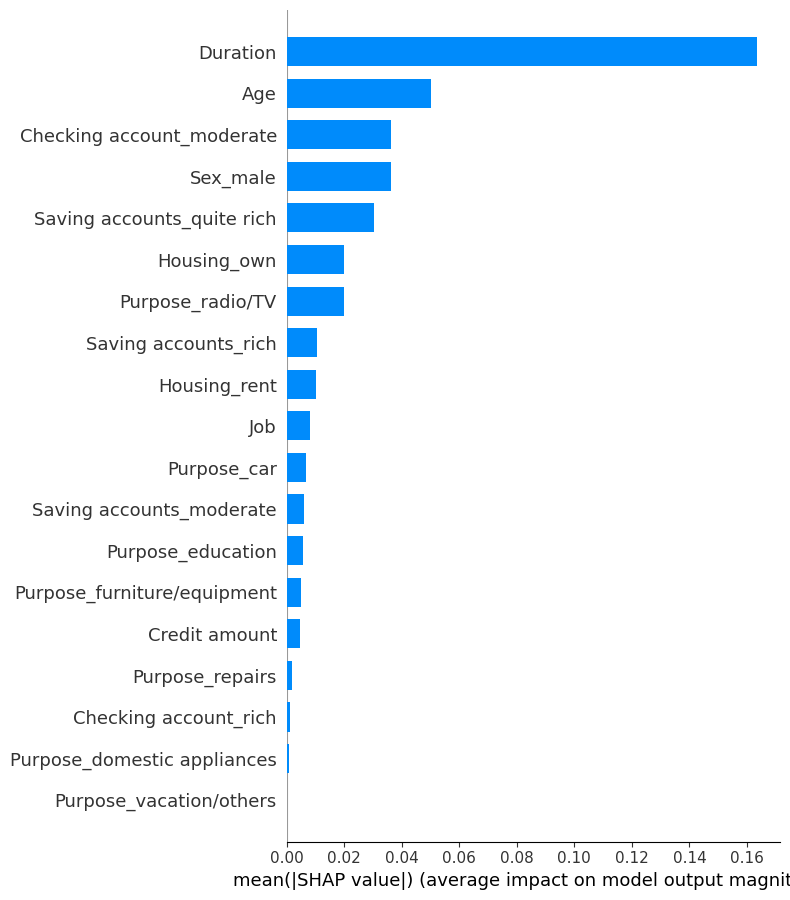

In [6]:
# Summary Plot
plt.figure(figsize=(8, 4))
shap.summary_plot(shap_values_riesgo, X_test, plot_type="bar")

#### Análisis del Gráfico SHAP (Importancia Global)
El gráfico clasifica las 19 características de tu modelo de riesgo crediticio según su impacto promedio en la predicción final.

- **Dominancia de "Duration":** La duración del préstamo es, por mucho, el factor más influyente. Indica que el tiempo que el cliente estará pagando es el principal predictor de riesgo.

- **Factores Demográficos y Financieros:** La edad (Age) y tener una cuenta corriente moderada (Checking account_moderate) le siguen en importancia.

- **Género:** El hecho de ser hombre (Sex_male) aparece con un peso relevante en las decisiones del modelo.

- **Variables de bajo impacto:** Al final de la lista vemos "Purpose_vacation/others" o "Purpose_repairs", lo que significa que el motivo del préstamo (si es para vacaciones o reparaciones) casi no afecta la decisión de otorgar el crédito.

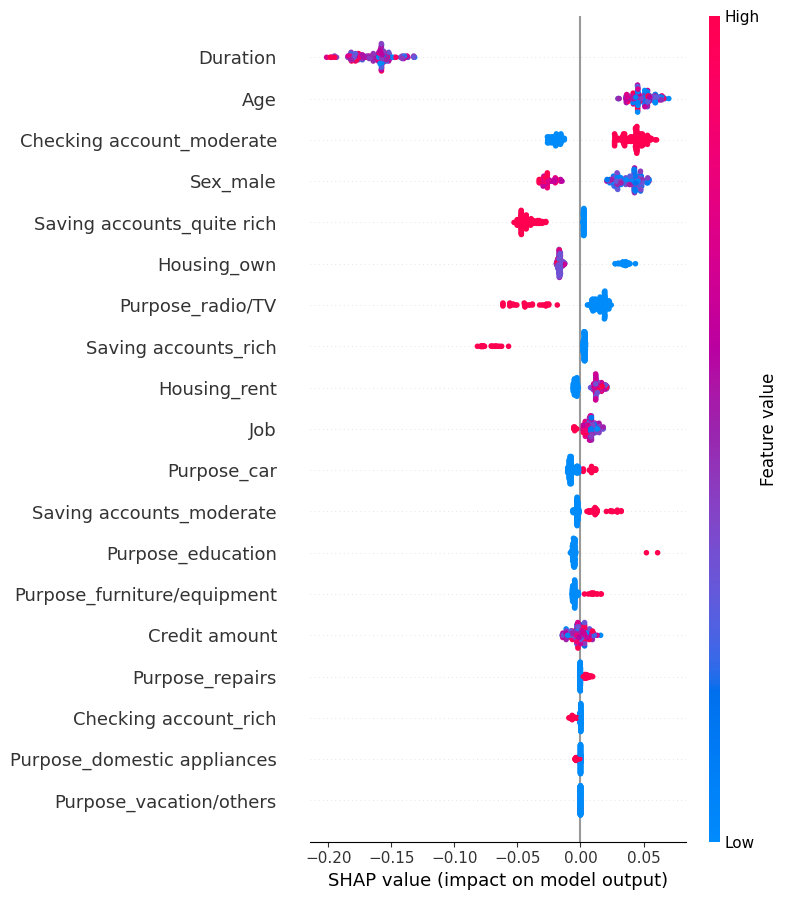

In [7]:
# Bee Swarm Plot
plt.figure(figsize=(8, 4))
shap.summary_plot(shap_values_riesgo, X_test)

#### Visualización de la Importancia Global (gráfico 2)
Las dos gráficas de SHAP que generaste son fundamentales para auditar tu modelo:

- **Summary Plot (Gráfico de barras - Imagen 2):**  Muestra la magnitud del impacto. Clasifica las variables según cuánto mueven la predicción en promedio. En el modelo, la **Duración** (Duration) y la **Edad** (Age) son, por mucho, los factores más importantes para determinar el riesgo.

- **Bee Swarm Plot (Gráfico de puntos - Imagen 3):** Este es el paso, no solo muestra importancia, sino dirección:

    - **Color:** El rojo indica valores altos de la variable y el azul valores bajos.

    - **Posición:** Si los puntos rojos están a la derecha del cero, un valor alto aumenta el riesgo.

    - **Ejemplo en de la gráfica:** Para Age (Edad), los puntos azules están a la derecha, lo que sugiere que ser más joven (valor bajo) está aumentando la predicción de riesgo en este modelo específico.

### 5. Explicación Individual (Paso 7 del Video)
Se elige al primer cliente para ver su Waterfall y Force Plot.

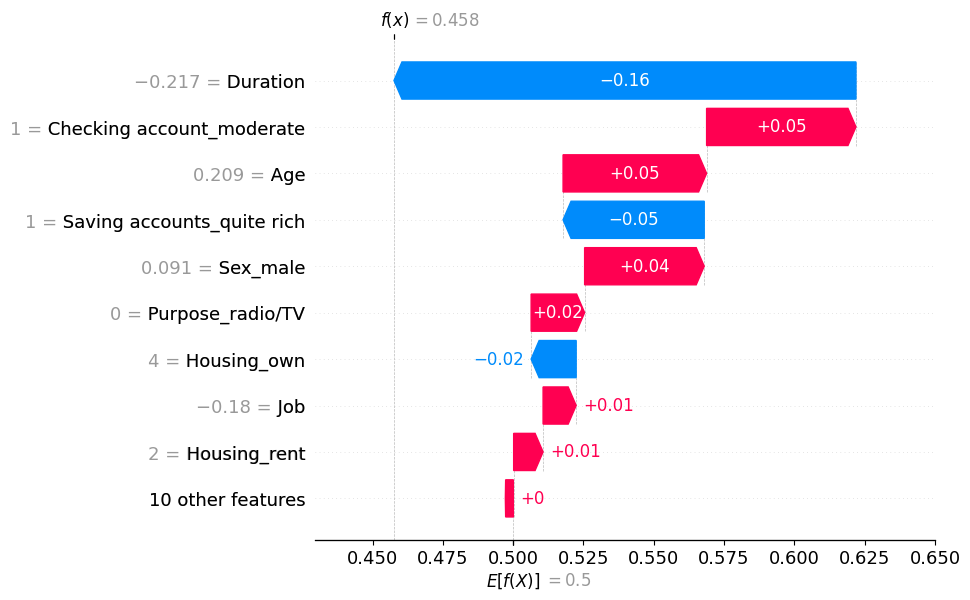

In [8]:
# Waterfall Plot
plt.figure(figsize=(8, 4))
# Crea un objeto Explanation específico para la clase 1 del cliente 0
exp_cliente_0 = shap.Explanation(
    values=shap_values_riesgo[0],
    base_values=explainer.expected_value[1],
    data=X_test.iloc[0],
    feature_names=cols_modelo
)
shap.plots.waterfall(exp_cliente_0)

# Force Plot 
shap.initjs()
shap.plots.force(exp_cliente_0)

 #### Interpretación del Waterfall Plot e Individual (Imagen 4)
 
 Estás analizando al Cliente #0.
 
- **Punto de Partida** ($E[f(X)] = 0.5$): Es el valor base o promedio. Sin saber nada del cliente, el modelo asume un riesgo del **50%**.
- **Predicción Final** ($f(x) = 0.458$): Después de analizar los datos del cliente # 0, el modelo bajó su riesgo a **45.8%**.
- **¿Qué lo salvó? (Flechas Azules):** La **Duración (Duration)** fue el factor clave. Al tener un valor de $-0.217$ (escalado), restó **-0.16** al riesgo, alejándolo del peligro.
- **¿Qué lo perjudicó?** (Flechas Rojas): Tener una cuenta corriente moderada **(Checking account_moderate)** y su **Edad (Age)** sumaron **+0.05** cada una al riesgo.

#### Visión Global y Bee Swarm (Imágen 3)
Esto corresponde al Paso 6 (Importancia Global).

- **Importancia Absoluta (Imagen 2):** Confirma que **Duration y Age** son las variables que más *"mandan"* en el modelo. Si se desea mejorar el modelo, hay que enfocarte en la calidad de esos datos.

- **Dirección del Impacto (Imagen 3):**

    - La variable **Age:** Los puntos azules (jóvenes) están a la derecha del cero, lo que significa que ser joven aumenta el riesgo en el an{alisis de este modelo.

    - Los puntos rojos (mayores) están a la izquierda, esto significa que **ser mayor disminuye el riesgo** en la predicción.

#### 6. Interpretación Log-Odds a Probabilidades
Traducción de los valores abstractos de SHAP a porcentajes de riesgo bancario.

In [9]:
def to_prob(log_odds):
    return 1 / (1 + np.exp(-log_odds))

base_log_odds = explainer.expected_value[1]
total_log_odds = base_log_odds + shap_values_riesgo[0].sum()

print(f"Probabilidad Promedio (Base): {to_prob(base_log_odds):.2%}")
print(f"Probabilidad de este Cliente: {to_prob(total_log_odds):.2%}")

Probabilidad Promedio (Base): 62.25%
Probabilidad de este Cliente: 61.24%


In [10]:
# Definir la ruta de guardado en los artefactos
path_explicacion = root / "artifacts" / "shap_explanation.pkl"

# Guarda el objeto completo (incluye valores base, datos y valores SHAP)
joblib.dump(shap_explanation, path_explicacion)

print("✅ Éxito: Explicación SHAP guardada para el Dashboard.")

✅ Éxito: Explicación SHAP guardada para el Dashboard.


![texto](img\image_dashboard.png)

**Credit Risk Analyzer Pro**

Aquí se presenta un desglose de lo que sucede en el sistema paso a paso:

- **1. Entrada de Datos (Panel Izquierdo)**
  
El proceso comienza con los **Parámetros del Cliente**. El sistema toma variables demográficas y financieras, como la **edad (30 años)**, el **sexo (femenino)**, el tipo de **vivienda (propia)** y el propósito del **crédito (automóvil)**. En el ejemplo, se solicita un monto de **5000** a pagar en **24** meses.

- **2. Procesamiento de ML y Score de Riesgo**
  
- **El Modelo analiza estos datos y genera un **Score de Riesgo del 50.17%.**
- **Alerta Roja:** Debido a que supera el umbral de seguridad, el sistema emite una advertencia de **"Alta Probabilidad de Default"** (impago).
  
- **3. Explicabilidad de la Decisión (SHAP)**
  
Lo más avanzado de esta herramienta es que explica el "porqué" mediante dos gráficos:

- **Force Plot:*** Muestra cómo las variables empujan el riesgo hacia arriba (rojo) o hacia abajo (azul).
- **Waterfall (Cascada):** Aquí vemos que la **Duración de 24 meses** es el factor que más incrementa el riesgo (+0.19), mientras que la **Edad** ayuda ligeramente a reducirlo (-0.08).
- 
- **4. Simulación "What-If"**
  
En la parte inferior, el sistema permite ajustar el monto simulado (en este caso a 1533) para ver cómo cambiaría el riesgo si se modificaran las condiciones del préstamo antes de tomar una decisión final.